<a href="https://colab.research.google.com/github/ezh2020/FloodRoad-SAM3/blob/main/FloodRoad_SAM3_Colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# FloodRoad-SAM3  Demo

复现实验请使用 **A100Highmem**,请在secret中添加 `HF_TOKEN`（需要有 **Meta/SAM3** 模型的访问权限）.



我们没有验证过代码在其他GPU与数据集上的运行情况.

## 1. 准备代码和运行环境


In [11]:
import os
import shutil
import subprocess
import sys
import urllib.request
from pathlib import Path

REPO_URL = "https://github.com/ezh2020/FloodRoad-SAM3.git"
REPO_DIR = Path("/content/FloodRoad-SAM3")
VENV_DIR = Path("/content/floodroad_venv")
PYTHON = VENV_DIR / "bin" / "python"
BASE_PYTHON = Path("/usr/local/bin/python3") if Path("/usr/local/bin/python3").exists() else Path(sys.executable)
VIRTUALENV_PYZ = Path("/content/virtualenv.pyz")

def run(cmd, **kwargs):
    print("+", " ".join(map(str, cmd)), flush=True)
    result = subprocess.run(cmd, text=True, **kwargs)
    if result.returncode != 0:
        raise RuntimeError(f"Command failed ({result.returncode}): {' '.join(map(str, cmd))}")
    return result

def create_venv():
    print("Base Python for venv:", BASE_PYTHON, flush=True)
    result = subprocess.run([str(BASE_PYTHON), "-m", "venv", "--system-site-packages", str(VENV_DIR)], text=True)
    if result.returncode == 0:
        return
    print("python -m venv failed; using virtualenv.pyz fallback.", flush=True)
    if not VIRTUALENV_PYZ.exists():
        urllib.request.urlretrieve("https://bootstrap.pypa.io/virtualenv.pyz", VIRTUALENV_PYZ)
    run([str(BASE_PYTHON), str(VIRTUALENV_PYZ), "--system-site-packages", str(VENV_DIR)])

%cd /content
shutil.rmtree(REPO_DIR, ignore_errors=True)
shutil.rmtree(VENV_DIR, ignore_errors=True)
run(["git", "clone", "--depth", "1", REPO_URL, str(REPO_DIR)])
%cd /content/FloodRoad-SAM3
!git rev-parse --short HEAD
create_venv()
assert PYTHON.exists(), f"Virtual environment Python was not created at {PYTHON}"
run([str(PYTHON), "--version"])
run([str(PYTHON), "-m", "pip", "install", "-q", "--no-warn-conflicts", "--upgrade", "pip", "setuptools", "wheel"])
run([str(PYTHON), "-m", "pip", "install", "-q", "--no-warn-conflicts", "-r", "requirements.txt"])
run([str(PYTHON), "-m", "py_compile", "run_colab_real.py", "train.py", "evaluate.py", "data/preprocess_sn8.py", "data/preprocess.py", "data/dataset.py", "models/sam3_baseline.py", "models/floodroad_sam3.py", "models/vit_token_merging.py", "models/dca.py", "models/rgstm.py", "models/ccrl.py", "models/deeplabv3_baseline.py", "models/losses.py", "models/lora.py", "metrics.py", "utils.py", "colab_validate.py"])
os.environ["FLOODROAD_PYTHON"] = str(PYTHON)
os.environ["PATH"] = str(PYTHON.parent) + os.pathsep + os.environ.get("PATH", "")
print("Using isolated Python:", os.environ["FLOODROAD_PYTHON"])


/content
+ git clone --depth 1 https://github.com/ezh2020/FloodRoad-SAM3.git /content/FloodRoad-SAM3
/content/FloodRoad-SAM3
630df4a
Base Python for venv: /usr/bin/python3
python -m venv failed; using virtualenv.pyz fallback.
+ /usr/bin/python3 /content/virtualenv.pyz --system-site-packages /content/floodroad_venv
+ /content/floodroad_venv/bin/python --version
+ /content/floodroad_venv/bin/python -m pip install -q --no-warn-conflicts --upgrade pip setuptools wheel
+ /content/floodroad_venv/bin/python -m pip install -q --no-warn-conflicts -r requirements.txt
+ /content/floodroad_venv/bin/python -m py_compile run_colab_real.py train.py evaluate.py data/preprocess_sn8.py data/preprocess.py data/dataset.py models/sam3_baseline.py models/floodroad_sam3.py models/vit_token_merging.py models/dca.py models/rgstm.py models/ccrl.py models/deeplabv3_baseline.py models/losses.py models/lora.py metrics.py utils.py colab_validate.py
Using isolated Python: /content/floodroad_venv/bin/python


## 2. 加载 SAM3 权重访问凭证


In [12]:
import os
from google.colab import userdata

token = os.environ.get("HF_TOKEN") or os.environ.get("HUGGING_FACE_HUB_TOKEN") or userdata.get("HF_TOKEN")
assert token, "Missing Colab Secret named HF_TOKEN. Add it after your Hugging Face account has access to facebook/sam3."
os.environ["HF_TOKEN"] = token
os.environ["HUGGING_FACE_HUB_TOKEN"] = token
print("HF token loaded:", bool(token))


HF token loaded: True


## 3. 检查数据、依赖和 SAM3 接口


In [13]:
import os
import json
import subprocess
import sys
from pathlib import Path

validation_path = Path("/content/floodroad_runs/default/colab_validation.json")
validation_path.parent.mkdir(parents=True, exist_ok=True)
python_bin = os.environ.get("FLOODROAD_PYTHON", sys.executable)
cmd = [python_bin, "colab_validate.py", "--output", str(validation_path)]
print("+", " ".join(cmd), flush=True)
env = dict(os.environ)
env["PATH"] = str(Path(python_bin).parent) + os.pathsep + env.get("PATH", "")
subprocess.run(cmd, text=True, check=True, env=env)
validation = json.loads(validation_path.read_text())
os.environ["SN8_TARBALL"] = validation["sn8_tarball"]
print("SN8_TARBALL=", os.environ["SN8_TARBALL"])
print("SAM3 hits=", validation["sam3_hits"])
print("Validation metadata=", validation_path)


+ /content/floodroad_venv/bin/python colab_validate.py --output /content/floodroad_runs/default/colab_validation.json
SN8_TARBALL= Louisiana-East_Training_Public.tar.gz
SAM3 hits= [['sam3', 'build_sam3_image_model'], ['sam3.model_builder', 'build_sam3_image_model']]
Validation metadata= /content/floodroad_runs/default/colab_validation.json


## 4. 下载权重并运行推理验证


In [14]:
# DeepLab 权重链接留空时会重新训练；填入链接时下载权重并跳过训练。
DEEPLAB_CHECKPOINT_URL = "https://drive.google.com/file/d/11jH0ZLjF0yiOVczdEI3CXkNDcJTg_3vT/view?usp=drive_link"

# Ours 权重链接留空时会重新训练；填入链接时下载权重并跳过对应训练。
# 这里默认调用已训练权重下载链接进行推理和验证。
# 第一个链接是 ours_no_tm.pt；第二个链接是 ours_tm.pt。
OURS_NO_TM_CHECKPOINT_URL = "https://drive.google.com/file/d/1cJhELg7oJO1m9InxsSdEHmRzxOGkznve/view?usp=drive_link"
OURS_TM_CHECKPOINT_URL = "https://drive.google.com/file/d/1duyXfSxjpZ10CciLRPbJj6i1g-6DobAm/view?usp=drive_link"

# Leave source-domain fields empty to train DeepLab on the current Louisiana-East data.
DEEPLAB_SOURCE_LOCATION = ""
DEEPLAB_SOURCE_TARBALL = ""
DEEPLAB_SOURCE_LIMIT_RECORDS = 32

import os
import subprocess
os.environ["DEEPLAB_CHECKPOINT_URL"] = DEEPLAB_CHECKPOINT_URL.strip()
os.environ["OURS_NO_TM_CHECKPOINT_URL"] = OURS_NO_TM_CHECKPOINT_URL.strip()
os.environ["OURS_TM_CHECKPOINT_URL"] = OURS_TM_CHECKPOINT_URL.strip()

# Restore the adapter file from the checked-out repo state in case an earlier hot patch left bad indentation.
subprocess.run(["git", "checkout", "HEAD", "--", "models/sam3_baseline.py"], check=True)
subprocess.run([os.environ["FLOODROAD_PYTHON"], "-m", "py_compile", "models/sam3_baseline.py", "models/vit_token_merging.py", "run_colab_real.py", "train.py", "evaluate.py", "visualize_segments.py"], check=True)

help_probe = subprocess.run(
    [os.environ["FLOODROAD_PYTHON"], "run_colab_real.py", "--help"],
    text=True, stdout=subprocess.PIPE, stderr=subprocess.STDOUT,
)
if "--ours-no-tm-checkpoint-url" not in help_probe.stdout:
    print(help_probe.stdout)
    raise RuntimeError("run_colab_real.py is older than this notebook. Re-run section 1 to clone the latest repo, or run `git pull` in /content/FloodRoad-SAM3.")

cmd = [
    os.environ["FLOODROAD_PYTHON"], "run_colab_real.py",
    "--config", "configs/default.yaml",
    "--raw-root", "/content/spacenet8/raw",
    "--processed-root", "/content/spacenet8/processed",
    "--output-dir", "/content/floodroad_runs/default",
    "--sn8-tarball", os.environ["SN8_TARBALL"],
    "--skip-sam3-install",
]
if DEEPLAB_CHECKPOINT_URL.strip():
    cmd += ["--deeplab-checkpoint-url", DEEPLAB_CHECKPOINT_URL.strip()]
if OURS_NO_TM_CHECKPOINT_URL.strip():
    cmd += ["--ours-no-tm-checkpoint-url", OURS_NO_TM_CHECKPOINT_URL.strip()]
if OURS_TM_CHECKPOINT_URL.strip():
    cmd += ["--ours-tm-checkpoint-url", OURS_TM_CHECKPOINT_URL.strip()]
if not DEEPLAB_CHECKPOINT_URL.strip() and DEEPLAB_SOURCE_LOCATION.strip():
    cmd += ["--deeplab-source-location", DEEPLAB_SOURCE_LOCATION.strip()]
if not DEEPLAB_CHECKPOINT_URL.strip() and DEEPLAB_SOURCE_TARBALL.strip():
    cmd += ["--deeplab-source-tarball", DEEPLAB_SOURCE_TARBALL.strip()]
if not DEEPLAB_CHECKPOINT_URL.strip() and (DEEPLAB_SOURCE_LOCATION.strip() or DEEPLAB_SOURCE_TARBALL.strip()):
    cmd += [
        "--deeplab-source-raw-root", "/content/spacenet8/deeplab_source_raw",
        "--deeplab-source-processed-root", "/content/spacenet8/deeplab_source_processed",
        "--deeplab-source-limit-records", str(DEEPLAB_SOURCE_LIMIT_RECORDS),
    ]
print("+", " ".join(cmd), flush=True)
from pathlib import Path
log_path = Path("/content/floodroad_runs/default/run_colab_real_latest.log")
log_path.parent.mkdir(parents=True, exist_ok=True)
result = subprocess.run(cmd, text=True, stdout=subprocess.PIPE, stderr=subprocess.STDOUT)
log_path.write_text(result.stdout)
print(result.stdout[-20000:])
print("Full log:", log_path)
if result.returncode != 0:
    raise RuntimeError(f"run_colab_real.py failed with exit code {result.returncode}; see {log_path}")


+ /content/floodroad_venv/bin/python run_colab_real.py --config configs/default.yaml --raw-root /content/spacenet8/raw --processed-root /content/spacenet8/processed --output-dir /content/floodroad_runs/default --sn8-tarball Louisiana-East_Training_Public.tar.gz --skip-sam3-install --deeplab-checkpoint-url https://drive.google.com/file/d/11jH0ZLjF0yiOVczdEI3CXkNDcJTg_3vT/view?usp=drive_link --ours-no-tm-checkpoint-url https://drive.google.com/file/d/1cJhELg7oJO1m9InxsSdEHmRzxOGkznve/view?usp=drive_link --ours-tm-checkpoint-url https://drive.google.com/file/d/1duyXfSxjpZ10CciLRPbJj6i1g-6DobAm/view?usp=drive_link
paths:
  raw_root: /content/spacenet8/raw
  processed_root: /content/spacenet8/processed
  output_dir: /content/floodroad_runs/default
inputs:
  pre_glob: '**/*pre*.tif'
  post_glob: '**/*post*.tif'
  road_geojson_glob: '**/*road*.geojson'
  flood_label_glob: '**/*flood*.tif'
data:
  tile_size: 1024
  overlap: 128
  default_road_width_px: 8
  road_buffer_px: 16
  flood_threshold:

## 5. 实验结果


In [17]:
from pathlib import Path
from IPython.display import Markdown, display

out = Path("/content/floodroad_runs/default")
for name, title in [("accuracy_table.md", "精度对比"), ("efficiency_table.md", "效率对比")]:
    path = out / name
    print(f"\n===== {title}: {path} =====")
    if path.exists():
        display(Markdown(path.read_text()))
    else:
        print("missing")



===== 精度对比: /content/floodroad_runs/default/accuracy_table.md =====


| Method | Pixel F1 | Pixel IoU | Segment-F1 | Precision | Recall |
| --- | --- | --- | --- | --- | --- |
| DeepLabV3+ | 0.8181 | 0.6921 | 0.9608 | 0.7427 | 0.9104 |
| SAM3 text-only | 0.0301 | 0.0153 | 0.2101 | 0.0166 | 0.1599 |
| FloodRoad-SAM3 (Ours) | 0.9999 | 0.9997 | 0.9979 | 0.9997 | 1.0000 |



===== 效率对比: /content/floodroad_runs/default/efficiency_table.md =====


| Method | Inference time (ms) | FLOPs (G) | Peak VRAM (GB) | GPU |
| --- | --- | --- | --- | --- |
| DeepLabV3+ | 24.106 | 1312.944 | 0.654 | NVIDIA A100-SXM4-40GB |
| SAM3 text-only | 156.529 | backend-specific | 6.322 | NVIDIA A100-SXM4-40GB |
| Ours-noTM | 435.053 | backend-specific | 6.322 | NVIDIA A100-SXM4-40GB |
| Ours-TM | 284.115 | backend-specific | 3.610 | NVIDIA A100-SXM4-40GB |


## 6. 可视化展示


+ /content/floodroad_venv/bin/python visualize_segments.py --config /content/floodroad_runs/default/real_run.yaml --output-dir /content/floodroad_runs/default --sample-index 1 --summary-json /content/floodroad_runs/default/segment_visualizations/latest_sample.json
sample 1 of 20 id= 10300100AF395C00_2_18_62_0_24


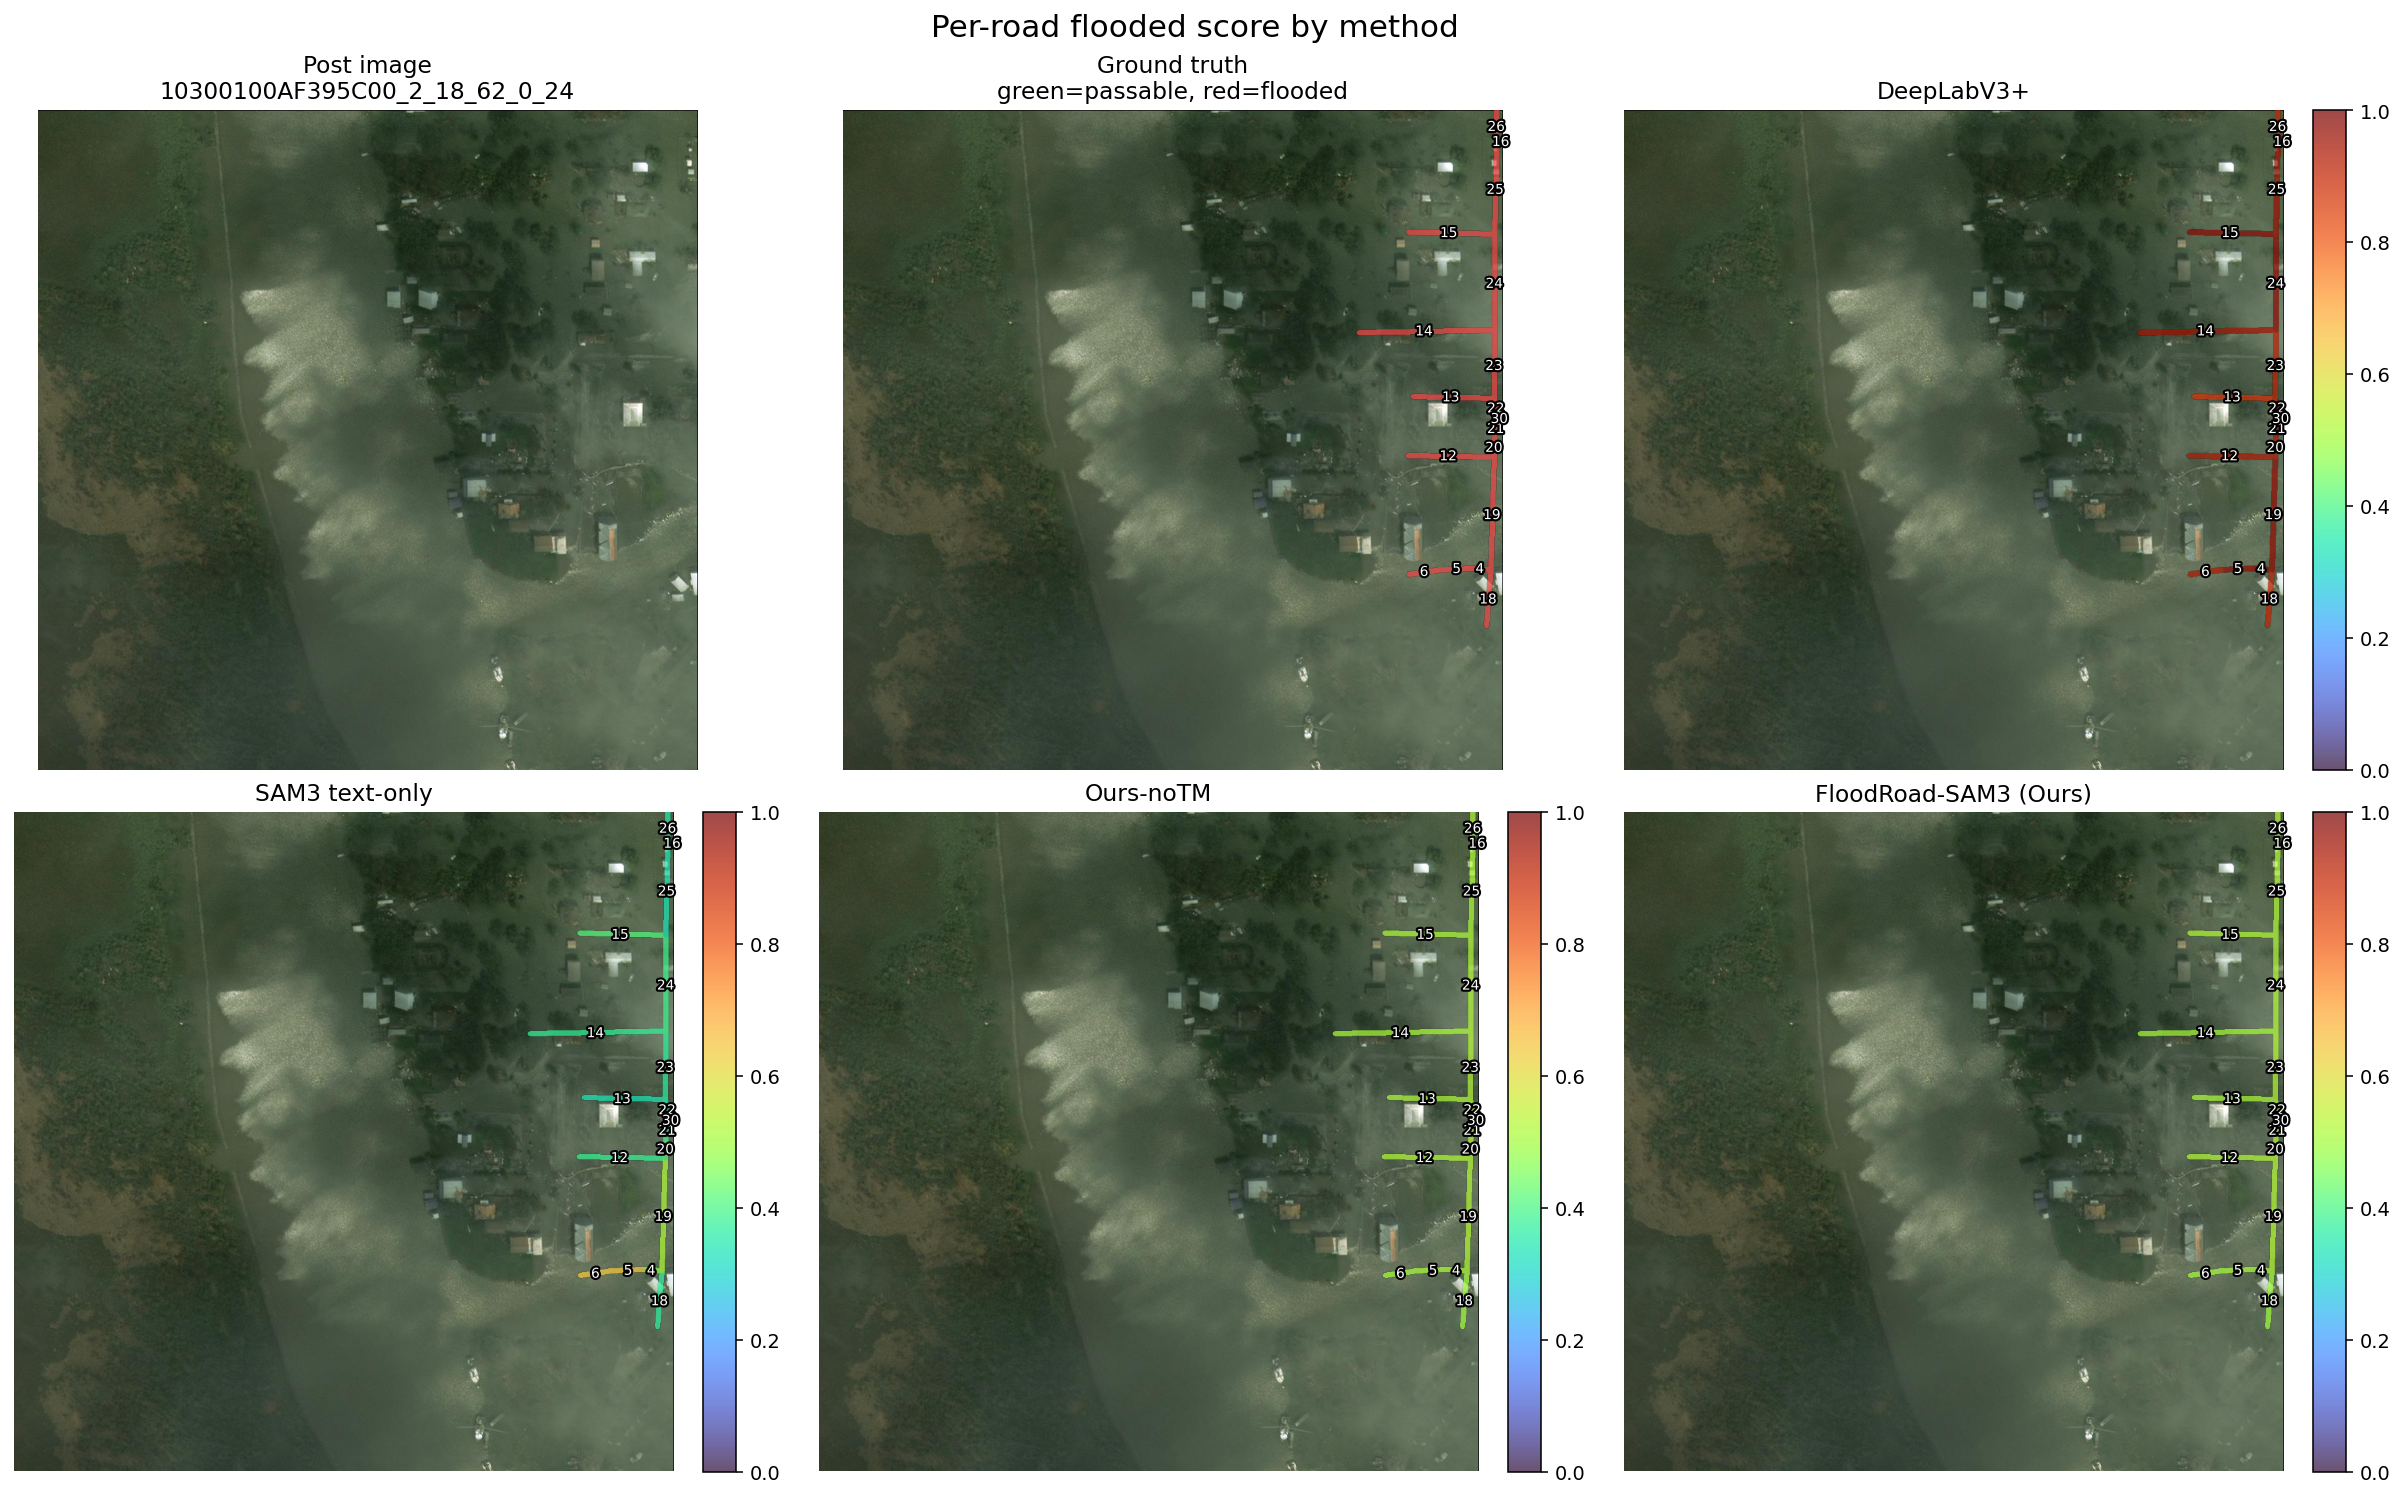

| segment_id | gt_flooded | road_pixels | DeepLabV3+ score | DeepLabV3+ pred | SAM3 text-only score | SAM3 text-only pred | Ours-noTM score | Ours-noTM pred | FloodRoad-SAM3 (Ours) score | FloodRoad-SAM3 (Ours) pred |
| --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- |
| 4.0 | 1.0 | 214.0 | 0.9939 | 1.0 | 0.4652 | 0.0 | 0.5044 | 1.0 | 0.5045 | 1.0 |
| 5.0 | 1.0 | 429.0 | 0.9729 | 1.0 | 0.6437 | 1.0 | 0.509 | 1.0 | 0.5097 | 1.0 |
| 6.0 | 1.0 | 492.0 | 0.9316 | 1.0 | 0.6329 | 1.0 | 0.5043 | 1.0 | 0.5005 | 1.0 |
| 12.0 | 1.0 | 1190.0 | 0.932 | 1.0 | 0.382 | 0.0 | 0.5184 | 1.0 | 0.5203 | 1.0 |
| 13.0 | 1.0 | 1117.0 | 0.8695 | 1.0 | 0.3381 | 0.0 | 0.5118 | 1.0 | 0.5088 | 1.0 |
| 14.0 | 1.0 | 1883.0 | 0.9477 | 1.0 | 0.3776 | 0.0 | 0.511 | 1.0 | 0.5055 | 1.0 |
| 15.0 | 1.0 | 1189.0 | 0.977 | 1.0 | 0.4126 | 0.0 | 0.5151 | 1.0 | 0.5208 | 1.0 |
| 16.0 | 1.0 | 45.0 | 0.8755 | 1.0 | 0.2944 | 0.0 | 0.512 | 1.0 | 0.5235 | 1.0 |
| 18.0 | 1.0 | 781.0 | 0.9079 | 1.0 | 0.3704 | 0.0 | 0.4986 | 0.0 | 0.4955 | 0.0 |
| 19.0 | 1.0 | 1575.0 | 0.9697 | 1.0 | 0.5124 | 1.0 | 0.522 | 1.0 | 0.5255 | 1.0 |
| 20.0 | 1.0 | 304.0 | 0.9318 | 1.0 | 0.4062 | 0.0 | 0.5256 | 1.0 | 0.5247 | 1.0 |
| 21.0 | 1.0 | 225.0 | 0.9556 | 1.0 | 0.3651 | 0.0 | 0.5307 | 1.0 | 0.5256 | 1.0 |
| 22.0 | 1.0 | 243.0 | 0.9715 | 1.0 | 0.3335 | 0.0 | 0.5276 | 1.0 | 0.524 | 1.0 |
| 23.0 | 1.0 | 954.0 | 0.9084 | 1.0 | 0.3684 | 0.0 | 0.524 | 1.0 | 0.5262 | 1.0 |
| 24.0 | 1.0 | 1341.0 | 0.9699 | 1.0 | 0.3892 | 0.0 | 0.5198 | 1.0 | 0.5201 | 1.0 |
| 25.0 | 1.0 | 1287.0 | 0.9538 | 1.0 | 0.3358 | 0.0 | 0.5133 | 1.0 | 0.5177 | 1.0 |
| 26.0 | 1.0 | 470.0 | 0.8951 | 1.0 | 0.3588 | 0.0 | 0.517 | 1.0 | 0.5302 | 1.0 |
| 30.0 | 1.0 | 83.0 | 0.9832 | 1.0 | 0.2981 | 0.0 | 0.5281 | 1.0 | 0.5283 | 1.0 |


In [16]:
SAMPLE_INDEX = 1

import json
import os
import subprocess
import sys
from pathlib import Path
from IPython.display import Image, display, Markdown

summary_path = Path('/content/floodroad_runs/default/segment_visualizations/latest_sample.json')
cmd = [
    os.environ.get('FLOODROAD_PYTHON', sys.executable), 'visualize_segments.py',
    '--config', '/content/floodroad_runs/default/real_run.yaml',
    '--output-dir', '/content/floodroad_runs/default',
    '--sample-index', str(SAMPLE_INDEX),
    '--summary-json', str(summary_path),
]
print('+', ' '.join(cmd), flush=True)
subprocess.run(cmd, check=True)
summary = json.loads(summary_path.read_text())
print('sample', summary['sample_index'], 'of', summary['sample_count'], 'id=', summary['sample_id'])
display(Image(filename=summary['figure']))
display(Markdown(Path(summary['markdown']).read_text()))
